<a href="https://colab.research.google.com/github/shyjuwilsonskt/deepfake-forensics-lab/blob/main/notebooks/01_fft_baseline_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

def analyze_frequency_domain(image_path_or_url):
    # Download or read image
    if image_path_or_url.startswith('http'):
        # Add a User-Agent header so the server accepts the request
        req = urllib.request.Request(
            image_path_or_url,
            headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        )
        resp = urllib.request.urlopen(req)
        image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
        img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread(image_path_or_url, cv2.IMREAD_GRAYSCALE)

    # Compute 2D Fast Fourier Transform
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    # Calculate Magnitude Spectrum (log scale for visual clarity)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)

    return img, magnitude_spectrum

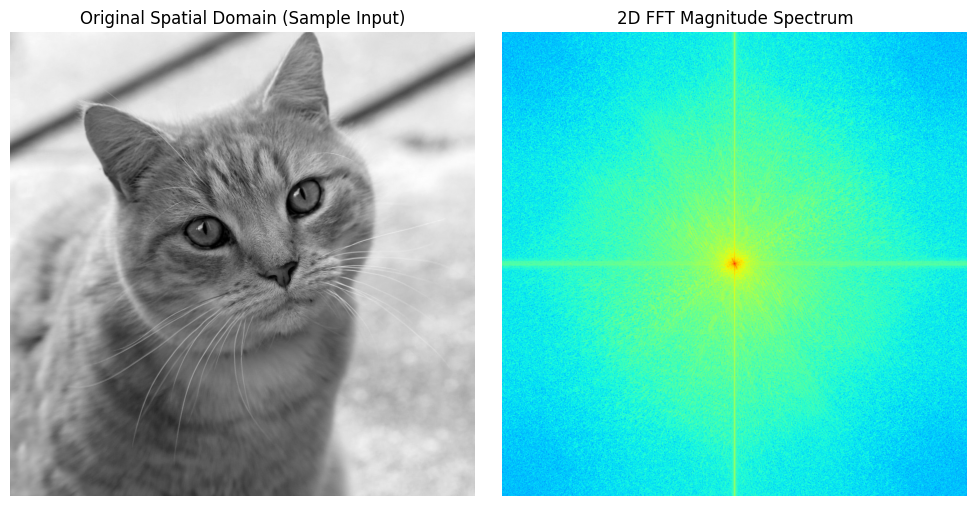

In [3]:
# --- Plotting Helper ---
def plot_forensic_comparison(img, magnitude_spectrum, title="Image Analysis"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f"Original Spatial Domain ({title})")
    axes[0].axis('off')

    axes[1].imshow(magnitude_spectrum, cmap='jet')
    axes[1].set_title("2D FFT Magnitude Spectrum")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# --- Run Analysis ---
sample_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
img, spec = analyze_frequency_domain(sample_url)
plot_forensic_comparison(img, spec, title="Sample Input")